In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv(
    r"C:\Users\krish patil\Downloads\data clean powe\python project\surat_cleanedd.csv"
)

print("✅ Dataset Loaded Successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

✅ Dataset Loaded Successfully
Rows: 4416
Columns: 14


In [3]:
df.columns.tolist()

['property_name',
 'areaWithType',
 'square_feet',
 'transaction',
 'status',
 'floor',
 'furnishing',
 'facing',
 'description',
 'price_per_sqft',
 'price',
 'area_type',
 'property_type',
 'bhk']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4416 entries, 0 to 4415
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   property_name   4416 non-null   object 
 1   areaWithType    4416 non-null   object 
 2   square_feet     4410 non-null   float64
 3   transaction     4416 non-null   object 
 4   status          4416 non-null   object 
 5   floor           4416 non-null   object 
 6   furnishing      4416 non-null   object 
 7   facing          4416 non-null   object 
 8   description     4416 non-null   object 
 9   price_per_sqft  4058 non-null   float64
 10  price           4244 non-null   float64
 11  area_type       4416 non-null   object 
 12  property_type   4416 non-null   object 
 13  bhk             3803 non-null   float64
dtypes: float64(4), object(10)
memory usage: 483.1+ KB


In [5]:
df.describe()

,square_feet,price_per_sqft,price,bhk
count,4.410000e+03,4.058000e+03,4.244000e+03,3803.000000
mean,4.107271e+03,9.463760e+03,1.331462e+07,2.839337
std,1.270930e+05,1.963796e+05,8.671071e+07,1.090685
min,1.000000e+00,1.000000e+00,1.000000e+05,1.000000
25%,8.000000e+02,3.651000e+03,4.227500e+06,2.000000
50%,1.252000e+03,4.697500e+03,7.100000e+06,3.000000
75%,2.000000e+03,6.236500e+03,1.330000e+07,3.000000
max,8.400000e+06,1.250000e+07,5.344400e+09,10.000000


In [6]:
df[[
    "square_feet",
    "price_per_sqft",
    "price",
    "bhk"
]].describe()

,square_feet,price_per_sqft,price,bhk
count,4.410000e+03,4.058000e+03,4.244000e+03,3803.000000
mean,4.107271e+03,9.463760e+03,1.331462e+07,2.839337
std,1.270930e+05,1.963796e+05,8.671071e+07,1.090685
min,1.000000e+00,1.000000e+00,1.000000e+05,1.000000
25%,8.000000e+02,3.651000e+03,4.227500e+06,2.000000
50%,1.252000e+03,4.697500e+03,7.100000e+06,3.000000
75%,2.000000e+03,6.236500e+03,1.330000e+07,3.000000
max,8.400000e+06,1.250000e+07,5.344400e+09,10.000000


In [7]:
print("PROPERTY TYPE")
print(df["property_type"].value_counts())

print("\nAREA TYPE")
print(df["area_type"].value_counts())

print("\nTRANSACTION")
print(df["transaction"].value_counts())

print("\nSTATUS")
print(df["status"].value_counts())

print("\nFURNISHING")
print(df["furnishing"].value_counts())

PROPERTY TYPE
property_type
Apartment    2968
House         540
Plot/Land     253
Shop          172
Villa         160
Office        152
Other         144
Showroom       26
Flat            1
Name: count, dtype: int64

AREA TYPE
area_type
Super Area     2542
Carpet Area    1626
Plot Area       207
Built Area       35
Status            4
Transaction       2
Name: count, dtype: int64

TRANSACTION
transaction
Resale                          2129
New Property                    1471
Unfurnished                      398
Unknown                          103
Semi-Furnished                    82
Furnished                         66
2                                 23
3                                 21
No                                19
Congo                             17
1                                 16
Yes                               15
5                                 10
4                                  7
Main Road                          5
Soham Elegance                     3


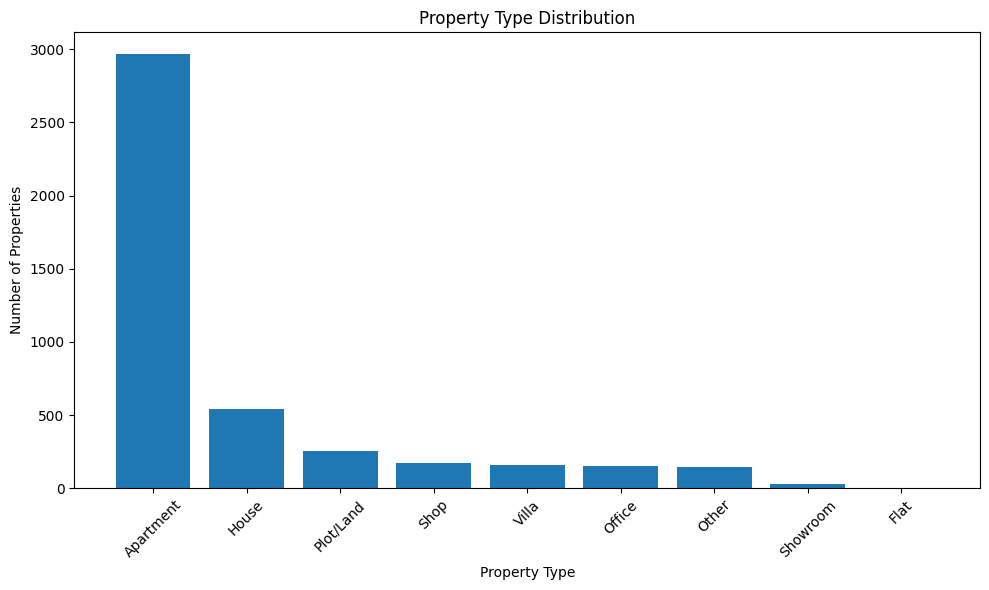

In [8]:
property_counts = df["property_type"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    property_counts.index,
    property_counts.values
)

plt.title("Property Type Distribution")
plt.xlabel("Property Type")
plt.ylabel("Number of Properties")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

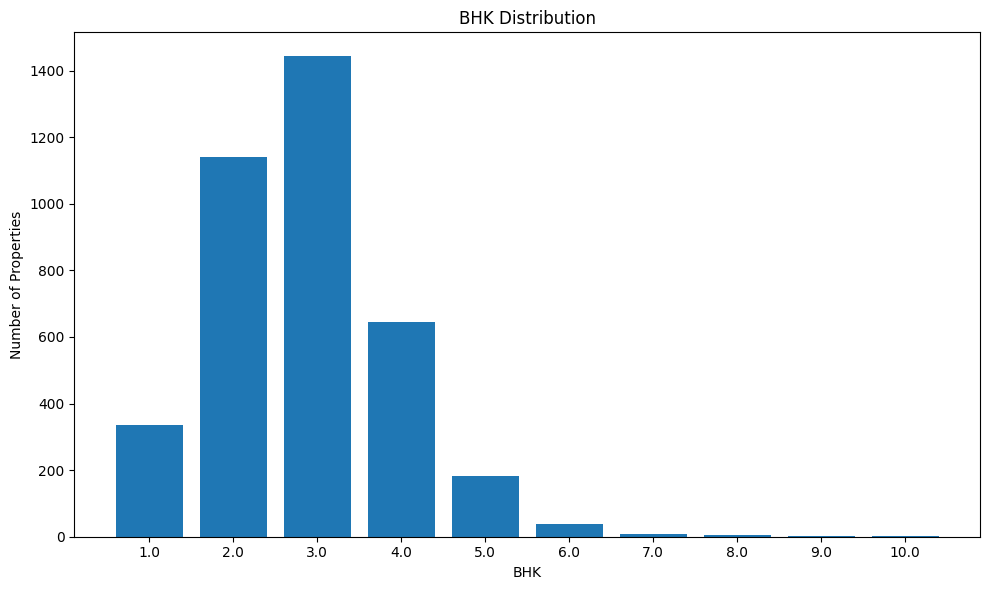

In [9]:
bhk_counts = df["bhk"].dropna().value_counts().sort_index()

plt.figure(figsize=(10, 6))

plt.bar(
    bhk_counts.index.astype(str),
    bhk_counts.values
)

plt.title("BHK Distribution")
plt.xlabel("BHK")
plt.ylabel("Number of Properties")

plt.tight_layout()
plt.show()

In [13]:
df["price_crore"] = df["price"] / 10000000

print(df["price_crore"].describe())

count    4244.000000
mean        1.331462
std         8.671071
min         0.010000
25%         0.422750
50%         0.710000
75%         1.330000
max       534.440000
Name: price_crore, dtype: float64


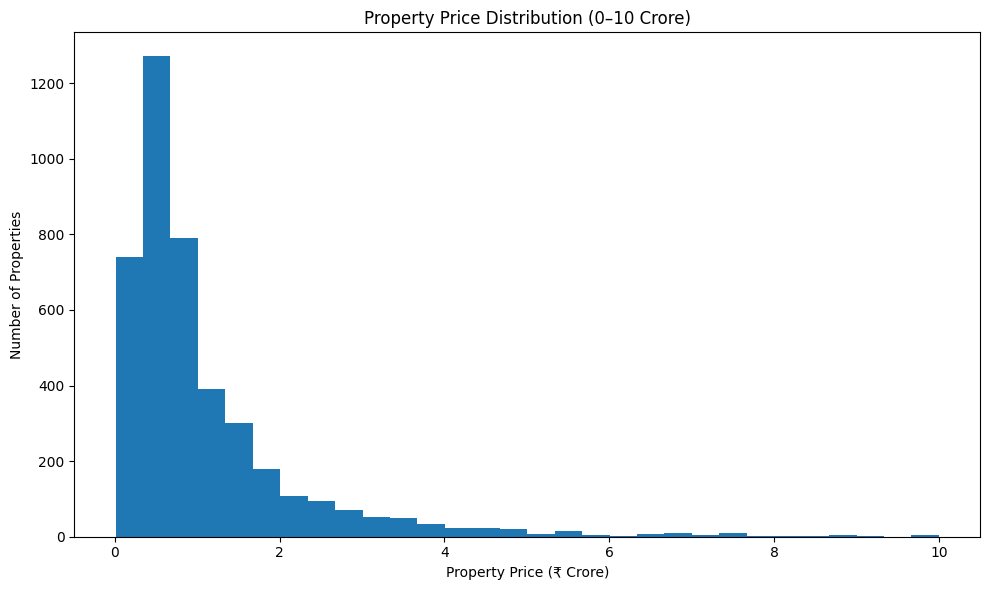

In [15]:
price_normal = df[
    (df["price_crore"] > 0) &
    (df["price_crore"] <= 10)
]

plt.figure(figsize=(10, 6))

plt.hist(
    price_normal["price_crore"],
    bins=30
)

plt.title("Property Price Distribution (0–10 Crore)")
plt.xlabel("Property Price (₹ Crore)")
plt.ylabel("Number of Properties")

plt.tight_layout()
plt.show()

In [16]:
print("Average Price:", round(df["price_crore"].mean(), 2), "Crore")
print("Median Price:", round(df["price_crore"].median(), 2), "Crore")

Average Price: 1.33 Crore
Median Price: 0.71 Crore


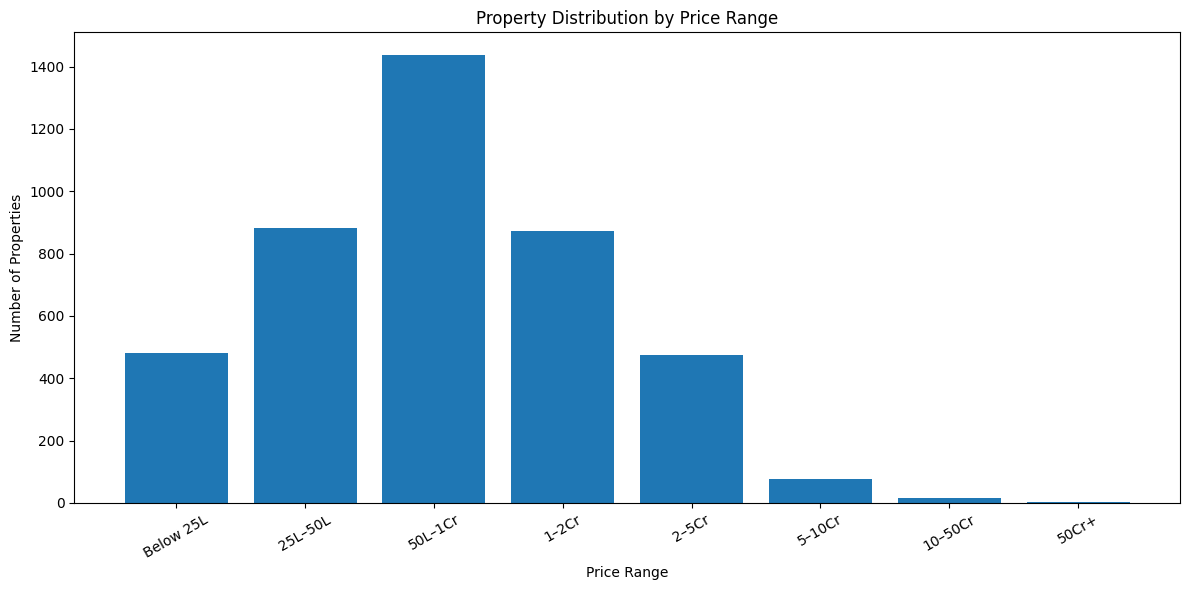

In [17]:
price_bins = [
    0,
    0.25,
    0.50,
    1,
    2,
    5,
    10,
    50,
    float("inf")
]

price_labels = [
    "Below 25L",
    "25L–50L",
    "50L–1Cr",
    "1–2Cr",
    "2–5Cr",
    "5–10Cr",
    "10–50Cr",
    "50Cr+"
]

df["price_category"] = pd.cut(
    df["price_crore"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

price_category_counts = df["price_category"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

plt.bar(
    price_category_counts.index.astype(str),
    price_category_counts.values
)

plt.title("Property Distribution by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Properties")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

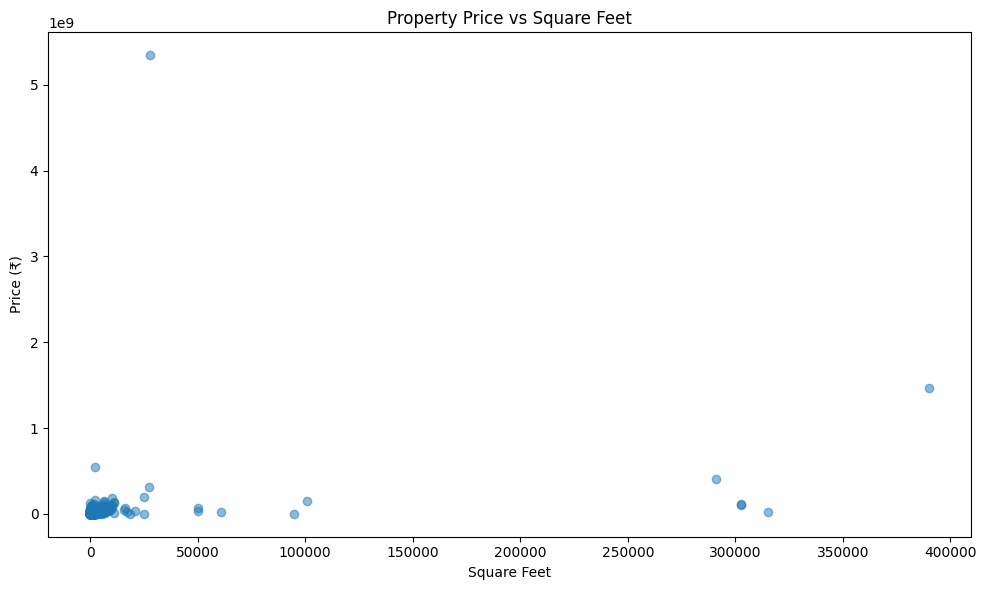

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["square_feet"],
    df["price"],
    alpha=0.5
)

plt.title("Property Price vs Square Feet")
plt.xlabel("Square Feet")
plt.ylabel("Price (₹)")

plt.tight_layout()
plt.show()

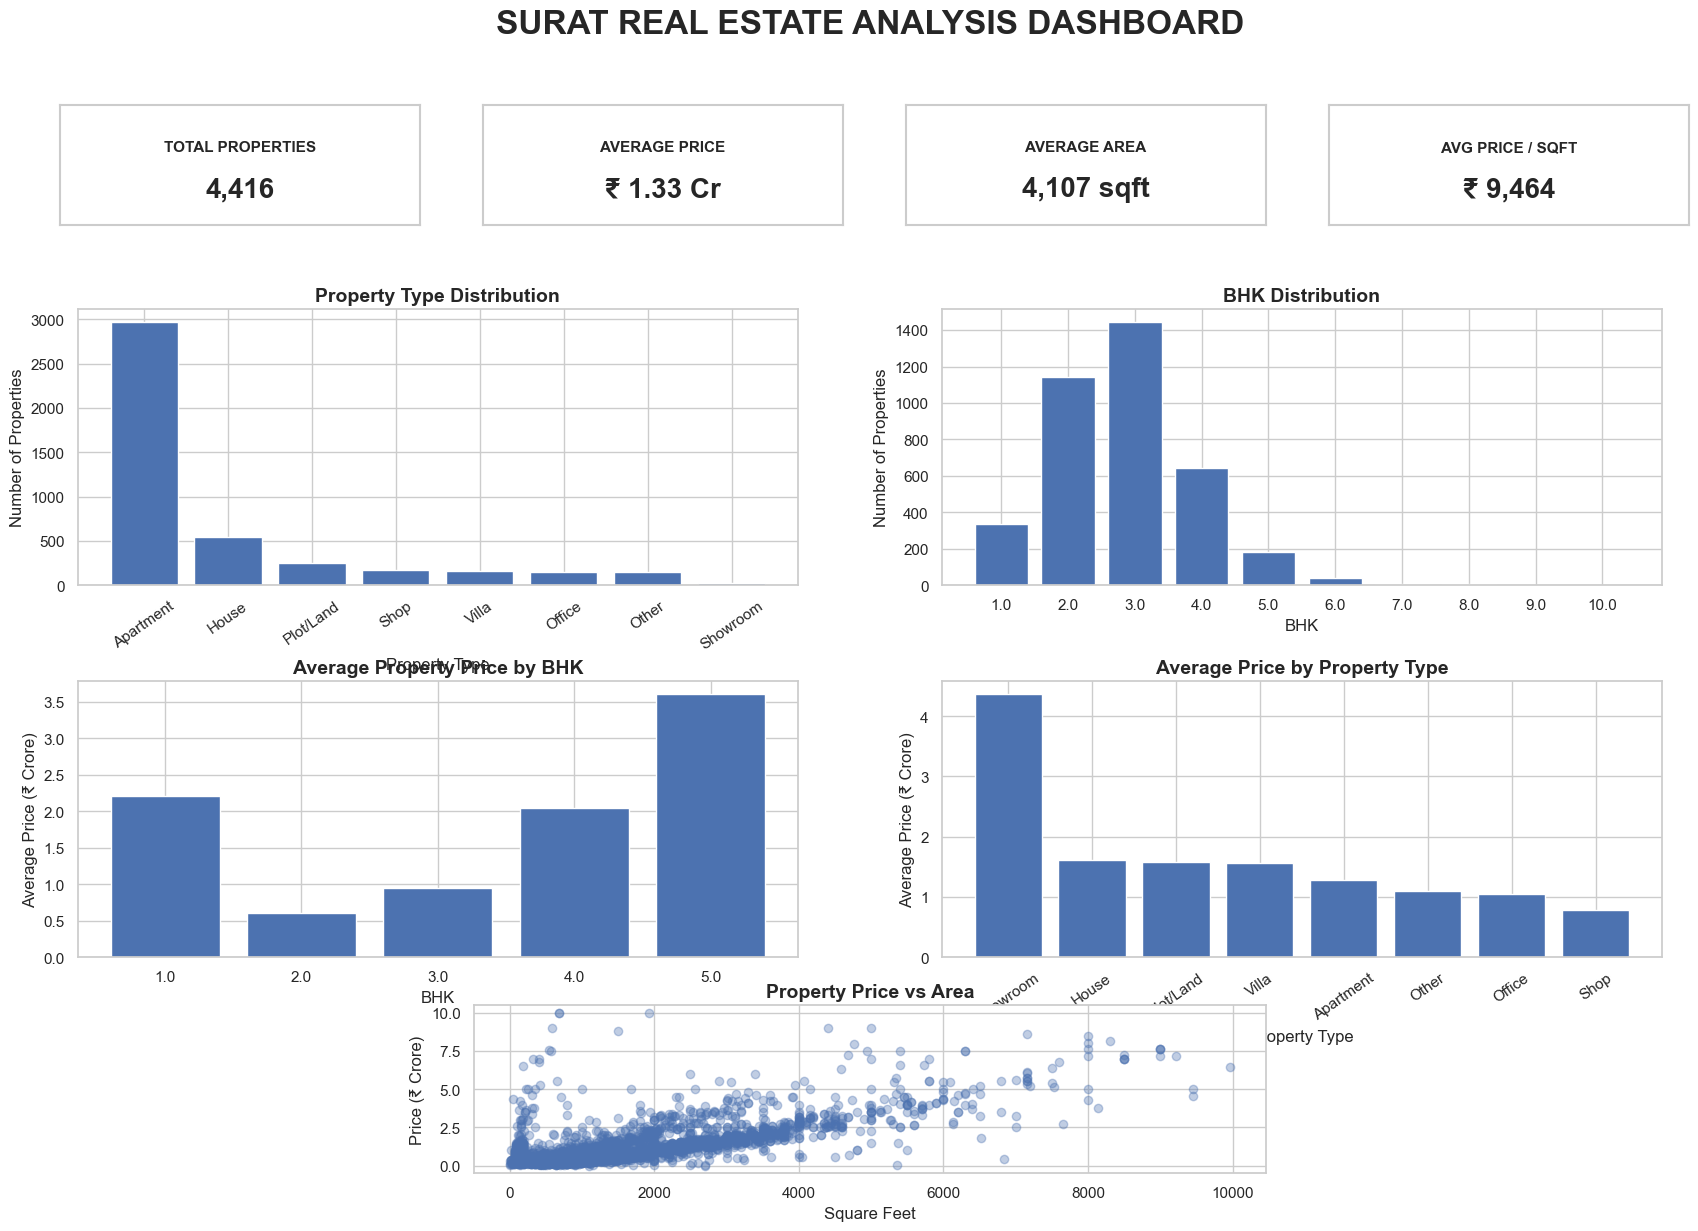

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------
# PREPARATION
# -----------------------------------------

# Price in Crores
if "price_crore" not in df.columns:
    df["price_crore"] = df["price"] / 10000000

# Remove invalid values only for visualization
analysis_df = df[
    (df["price"] > 0) &
    (df["square_feet"] > 0) &
    (df["price_per_sqft"] > 0)
].copy()


# -----------------------------------------
# KPI CALCULATIONS
# -----------------------------------------

total_properties = len(df)

avg_price = df["price_crore"].mean()

avg_area = df["square_feet"].mean()

avg_price_sqft = df["price_per_sqft"].mean()


# -----------------------------------------
# DASHBOARD
# -----------------------------------------

sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(18, 12))

fig.suptitle(
    "SURAT REAL ESTATE ANALYSIS DASHBOARD",
    fontsize=24,
    fontweight="bold",
    y=0.98
)



        title,# =========================================
# KPI CARDS
# =========================================

kpis = [
    ("TOTAL PROPERTIES", f"{total_properties:,.0f}"),
    ("AVERAGE PRICE", f"₹ {avg_price:.2f} Cr"),
    ("AVERAGE AREA", f"{avg_area:,.0f} sqft"),
    ("AVG PRICE / SQFT", f"₹ {avg_price_sqft:,.0f}")
]

for i, (title, value) in enumerate(kpis):

    ax = fig.add_axes([
        0.05 + i * 0.235,
        0.80,
        0.20,
        0.10
    ])

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)

    ax.text(
        0.5, 0.65,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.30,
        value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )


# =========================================
# 1. PROPERTY TYPE DISTRIBUTION
# =========================================

ax1 = fig.add_axes([0.06, 0.50, 0.40, 0.23])

property_counts = (
    df["property_type"]
    .value_counts()
    .head(8)
)

ax1.bar(
    property_counts.index,
    property_counts.values
)

ax1.set_title(
    "Property Type Distribution",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel("Property Type")
ax1.set_ylabel("Number of Properties")

ax1.tick_params(axis="x", rotation=35)


# =========================================
# 2. BHK DISTRIBUTION
# =========================================

ax2 = fig.add_axes([0.54, 0.50, 0.40, 0.23])

bhk_counts = (
    df["bhk"]
    .dropna()
    .value_counts()
    .sort_index()
)

ax2.bar(
    bhk_counts.index.astype(str),
    bhk_counts.values
)

ax2.set_title(
    "BHK Distribution",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel("BHK")
ax2.set_ylabel("Number of Properties")


# =========================================
# 3. AVERAGE PRICE BY BHK
# =========================================

ax3 = fig.add_axes([0.06, 0.19, 0.40, 0.23])

bhk_price = (
    df.dropna(subset=["bhk", "price_crore"])
    .groupby("bhk")["price_crore"]
    .mean()
)

# Keep reasonable BHK range for visualization
bhk_price = bhk_price[
    bhk_price.index <= 5
]

ax3.bar(
    bhk_price.index.astype(str),
    bhk_price.values
)

ax3.set_title(
    "Average Property Price by BHK",
    fontsize=14,
    fontweight="bold"
)

ax3.set_xlabel("BHK")
ax3.set_ylabel("Average Price (₹ Crore)")


# =========================================
# 4. PROPERTY TYPE VS AVERAGE PRICE
# =========================================

ax4 = fig.add_axes([0.54, 0.19, 0.40, 0.23])

type_price = (
    df.dropna(subset=["property_type", "price_crore"])
    .groupby("property_type")["price_crore"]
    .mean()
    .sort_values(ascending=False)
    .head(8)
)

ax4.bar(
    type_price.index,
    type_price.values
)

ax4.set_title(
    "Average Price by Property Type",
    fontsize=14,
    fontweight="bold"
)

ax4.set_xlabel("Property Type")
ax4.set_ylabel("Average Price (₹ Crore)")

ax4.tick_params(axis="x", rotation=35)


# =========================================
# 5. PRICE VS AREA
# =========================================

ax5 = fig.add_axes([0.28, 0.01, 0.44, 0.14])

scatter_df = analysis_df[
    (analysis_df["price_crore"] <= 10) &
    (analysis_df["square_feet"] <= 10000)
]

ax5.scatter(
    scatter_df["square_feet"],
    scatter_df["price_crore"],
    alpha=0.35
)

ax5.set_title(
    "Property Price vs Area",
    fontsize=14,
    fontweight="bold"
)

ax5.set_xlabel("Square Feet")
ax5.set_ylabel("Price (₹ Crore)")


plt.show()

In [21]:
# =========================
# DASHBOARD PREPARATION
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Price in Crores
df["price_crore"] = df["price"] / 10000000

# Visualization dataset
analysis_df = df[
    (df["price"] > 0) &
    (df["square_feet"] > 0) &
    (df["price_per_sqft"] > 0)
].copy()

# KPI calculations
total_properties = len(df)
avg_price = df["price_crore"].mean()
avg_area = df["square_feet"].mean()
avg_price_sqft = df["price_per_sqft"].mean()

print("Dashboard data prepared successfully ✅")

print("Total Properties:", total_properties)
print("Average Price:", round(avg_price, 2), "Cr")
print("Average Area:", round(avg_area, 0), "sqft")
print("Average Price/Sqft:", round(avg_price_sqft, 0))

Dashboard data prepared successfully ✅
Total Properties: 4416
Average Price: 1.33 Cr
Average Area: 4107.0 sqft
Average Price/Sqft: 9464.0


In [22]:
print(df.shape)
print(df[[
    "property_type",
    "bhk",
    "square_feet",
    "price_crore",
    "price_per_sqft"
]].head())

(4416, 16)
  property_type  bhk  square_feet  price_crore  price_per_sqft
0     Apartment  2.0        644.0        0.338          2891.0
1     Apartment  2.0       1278.0        0.454          3551.0
2     Apartment  2.0       1173.0        0.446          3800.0
3     Apartment  2.0        700.0        0.470          3966.0
4     Apartment  2.0       1250.0        0.450          3600.0


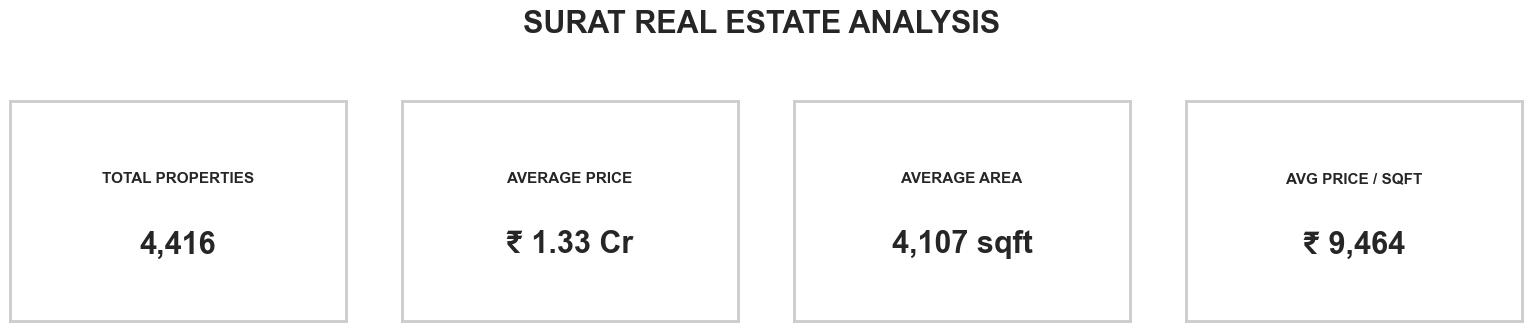

In [23]:
# =========================
# KPI CARDS
# =========================

fig = plt.figure(figsize=(16, 4))

fig.suptitle(
    "SURAT REAL ESTATE ANALYSIS",
    fontsize=22,
    fontweight="bold"
)

kpis = [
    ("TOTAL PROPERTIES", f"{total_properties:,}"),
    ("AVERAGE PRICE", f"₹ {avg_price:.2f} Cr"),
    ("AVERAGE AREA", f"{avg_area:,.0f} sqft"),
    ("AVG PRICE / SQFT", f"₹ {avg_price_sqft:,.0f}")
]

for i, (title, value) in enumerate(kpis):

    ax = fig.add_axes([
        0.03 + i * 0.245,
        0.20,
        0.21,
        0.55
    ])

    # Hide axis
    ax.set_xticks([])
    ax.set_yticks([])

    # Card border
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    # KPI title
    ax.text(
        0.5,
        0.65,
        title,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    # KPI value
    ax.text(
        0.5,
        0.35,
        value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

plt.show()

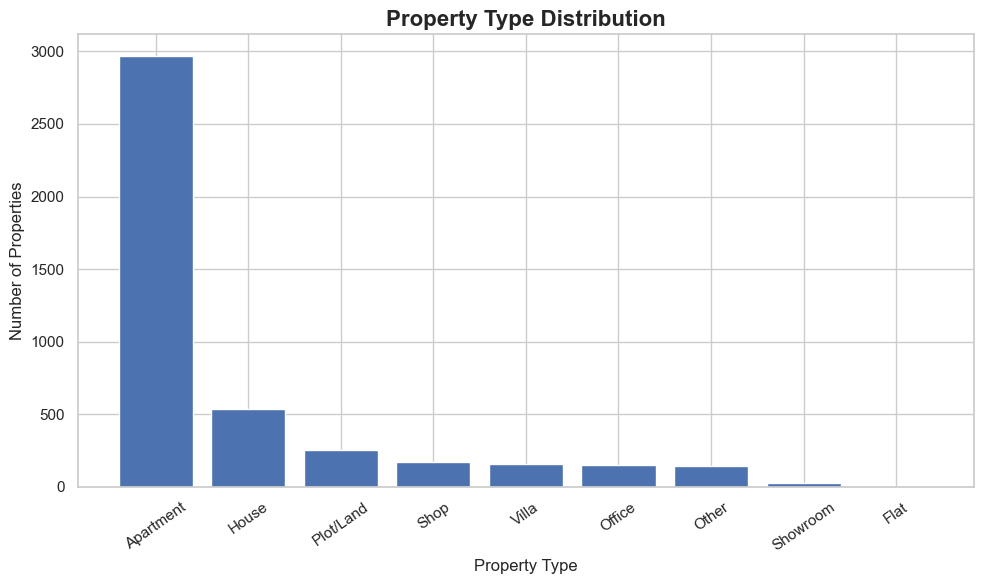

In [24]:
property_counts = df["property_type"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    property_counts.index,
    property_counts.values
)

plt.title(
    "Property Type Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Property Type")
plt.ylabel("Number of Properties")

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

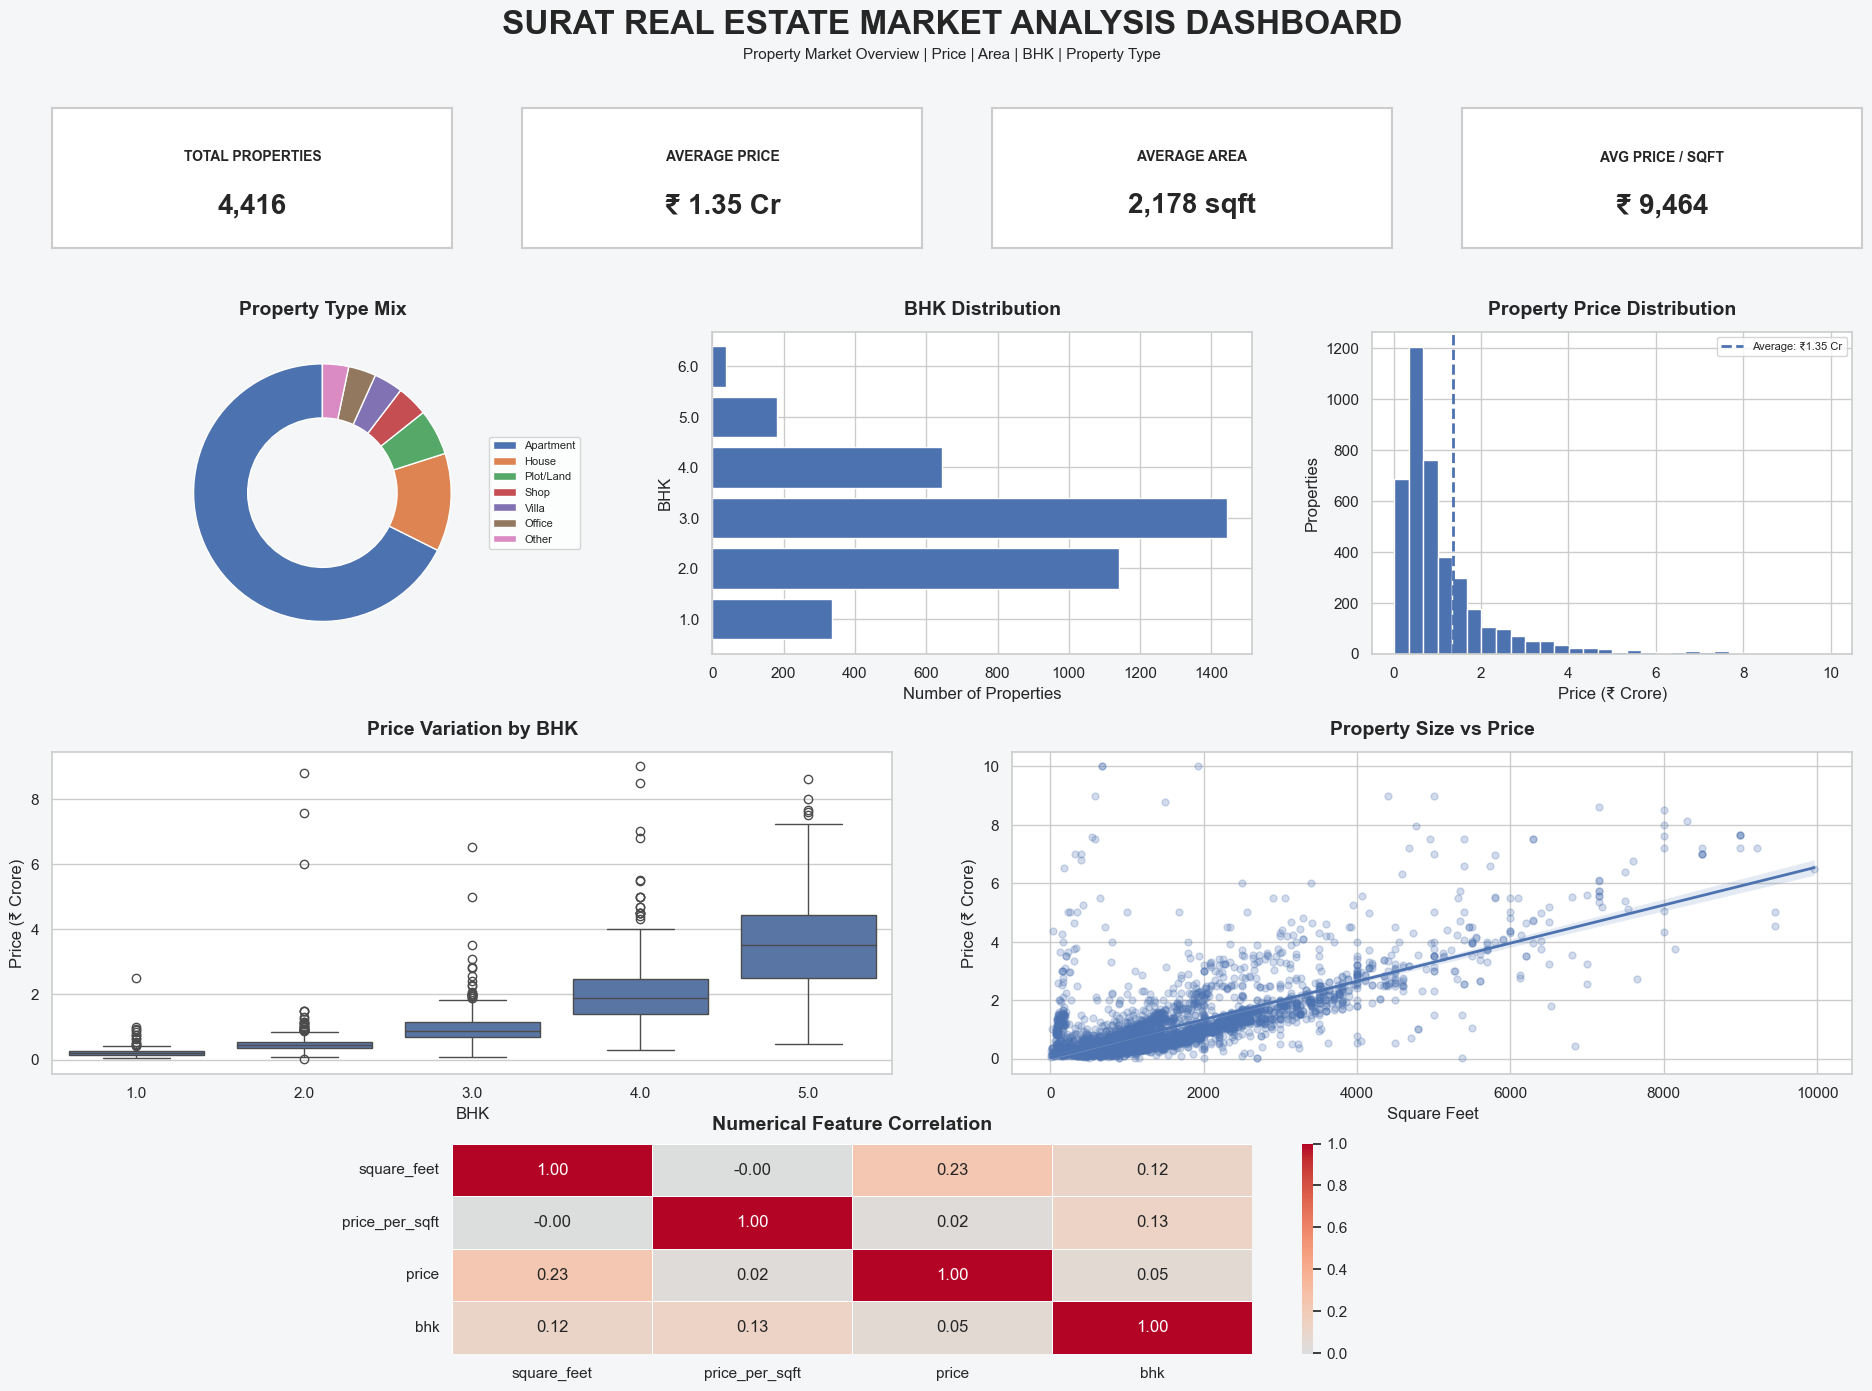

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# PREPARATION
# =====================================================

df["price_crore"] = df["price"] / 10000000

analysis_df = df[
    (df["price"] > 0) &
    (df["square_feet"] > 0) &
    (df["price_per_sqft"] > 0)
].copy()


# =====================================================
# KPI VALUES
# =====================================================

total_properties = len(df)

avg_price = analysis_df["price_crore"].mean()

avg_area = analysis_df["square_feet"].mean()

avg_price_sqft = analysis_df["price_per_sqft"].mean()


# =====================================================
# DASHBOARD STYLE
# =====================================================

sns.set_theme(style="whitegrid")

fig = plt.figure(
    figsize=(20, 14),
    facecolor="#F4F6F8"
)

fig.suptitle(
    "SURAT REAL ESTATE MARKET ANALYSIS DASHBOARD",
    fontsize=24,
    fontweight="bold",
    y=0.97
)

fig.text(
    0.5,
    0.935,
    "Property Market Overview | Price | Area | BHK | Property Type",
    ha="center",
    fontsize=11
)


# =====================================================
# KPI CARDS — SAME AS YOUR DESIGN
# =====================================================

kpis = [
    ("TOTAL PROPERTIES", f"{total_properties:,.0f}"),
    ("AVERAGE PRICE", f"₹ {avg_price:.2f} Cr"),
    ("AVERAGE AREA", f"{avg_area:,.0f} sqft"),
    ("AVG PRICE / SQFT", f"₹ {avg_price_sqft:,.0f}")
]

for i, (title, value) in enumerate(kpis):

    ax = fig.add_axes([
        0.05 + i * 0.235,
        0.80,
        0.20,
        0.10
    ])

    # Card background
    ax.set_facecolor("white")

    # Remove ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # Card border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)

    # KPI TITLE
    ax.text(
        0.5,
        0.65,
        title,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    # KPI VALUE
    ax.text(
        0.5,
        0.30,
        value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )


# =====================================================
# GRAPH PANEL FUNCTION
# =====================================================

def style_panel(ax, title):

    ax.set_facecolor("white")

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=12
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)


# =====================================================
# 1. DONUT CHART
# PROPERTY TYPE MIX
# =====================================================

ax1 = fig.add_axes([
    0.05, 0.51, 0.27, 0.23
])

style_panel(ax1, "Property Type Mix")

property_counts = (
    df["property_type"]
    .value_counts()
    .head(7)
)

wedges, texts = ax1.pie(
    property_counts.values,
    startangle=90,
    wedgeprops=dict(
        width=0.42,
        edgecolor="white"
    )
)

ax1.legend(
    wedges,
    property_counts.index,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=8
)


# =====================================================
# 2. HORIZONTAL BAR
# BHK DISTRIBUTION
# =====================================================

ax2 = fig.add_axes([
    0.38, 0.51, 0.27, 0.23
])

style_panel(ax2, "BHK Distribution")

bhk_counts = (
    df["bhk"]
    .dropna()
    .value_counts()
    .sort_index()
)

bhk_counts = bhk_counts[
    bhk_counts.index <= 6
]

ax2.barh(
    bhk_counts.index.astype(str),
    bhk_counts.values
)

ax2.set_xlabel("Number of Properties")
ax2.set_ylabel("BHK")


# =====================================================
# 3. HISTOGRAM
# PRICE DISTRIBUTION
# =====================================================

ax3 = fig.add_axes([
    0.71, 0.51, 0.24, 0.23
])

style_panel(ax3, "Property Price Distribution")

price_view = analysis_df[
    analysis_df["price_crore"] <= 10
]

ax3.hist(
    price_view["price_crore"],
    bins=30
)

ax3.axvline(
    avg_price,
    linestyle="--",
    linewidth=2,
    label=f"Average: ₹{avg_price:.2f} Cr"
)

ax3.set_xlabel("Price (₹ Crore)")
ax3.set_ylabel("Properties")

ax3.legend(fontsize=8)


# =====================================================
# 4. BOX PLOT
# PRICE BY BHK
# =====================================================

ax4 = fig.add_axes([
    0.05, 0.21, 0.42, 0.23
])

style_panel(ax4, "Price Variation by BHK")

box_df = analysis_df[
    (analysis_df["bhk"] >= 1) &
    (analysis_df["bhk"] <= 5) &
    (analysis_df["price_crore"] <= 10)
].copy()

sns.boxplot(
    data=box_df,
    x="bhk",
    y="price_crore",
    ax=ax4
)

ax4.set_xlabel("BHK")
ax4.set_ylabel("Price (₹ Crore)")


# =====================================================
# 5. SCATTER PLOT
# AREA VS PRICE
# =====================================================

ax5 = fig.add_axes([
    0.53, 0.21, 0.42, 0.23
])

style_panel(ax5, "Property Size vs Price")

scatter_df = analysis_df[
    (analysis_df["square_feet"] <= 10000) &
    (analysis_df["price_crore"] <= 10)
]

sns.regplot(
    data=scatter_df,
    x="square_feet",
    y="price_crore",
    scatter_kws={
        "alpha": 0.25,
        "s": 25
    },
    line_kws={
        "linewidth": 2
    },
    ax=ax5
)

ax5.set_xlabel("Square Feet")
ax5.set_ylabel("Price (₹ Crore)")


# =====================================================
# 6. HEATMAP
# CORRELATION
# =====================================================

ax6 = fig.add_axes([
    0.25, 0.01, 0.50, 0.15
])

corr_columns = [
    "square_feet",
    "price_per_sqft",
    "price",
    "bhk"
]

corr = analysis_df[corr_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax6
)

ax6.set_title(
    "Numerical Feature Correlation",
    fontsize=14,
    fontweight="bold",
    pad=10
)


# =====================================================
# FINAL LAYOUT
# =====================================================

plt.show()